<a href="https://colab.research.google.com/github/Bhavana-Mahesh29/pollution-hotspot-ml/blob/main/mlfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Urban Pollution Hotspot Identification & Green Infrastructure Recommendation

**Objective:** Classify areas into pollution zones (Low / Medium / High) using air quality features, then recommend appropriate green solutions such as trees, green roofs, urban parks, and vertical gardens.

**Pipeline Overview:**
1. Data Loading & Inspection
2. Data Preprocessing (cleaning, encoding, outlier handling)
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Target Variable Creation (before scaling)
6. Feature Scaling & Train-Test Split
7. Baseline Model Training & Evaluation
8. Model Comparison
9. Green Infrastructure Recommendation System

## 1. Data Loading & Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("/content/MLfeb8.xlsx")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData Types & Null Counts:")
df.info()

Shape: (8228, 11)

First 5 rows:


,Date,District 2,SO2,NO2,CO,PM2.5,PM10,AQIValue,lat,long,ProminentPollutant
0,01-01-2024,Ariyalur,9,11,0.2,15,32,32.0,11.1380,11.1380,PM10
1,01-01-2024,Chengalpattu (Vandalur),12,15,0.6,25,38,41.0,12.6819,79.9888,PM2.5
2,01-01-2024,Chennai Kodungaiyur,12,201,0.6,12,50,50.0,13.1375,80.2478,PM10
3,01-01-2024,Koyambedu,6,9,-,14,-111,53.0,13.0694,80.1948,PM10
4,01-01-2024,Perungudi,3,15,0.6,18,99,99.0,12.9654,80.2461,PM10



Data Types & Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                8228 non-null   object 
 1   District 2          8228 non-null   object 
 2   SO2                 7844 non-null   object 
 3   NO2                 7240 non-null   object 
 4   CO                  7239 non-null   object 
 5   PM2.5               7236 non-null   object 
 6   PM10                7240 non-null   object 
 7   AQIValue            7240 non-null   float64
 8   lat                 8228 non-null   float64
 9   long                8228 non-null   float64
 10  ProminentPollutant  8228 non-null   object 
dtypes: float64(3), object(8)
memory usage: 707.2+ KB


## 2. Data Preprocessing

### 2.1 Convert Pollutant Columns to Numeric

In [ ]:
pollutant_cols = ["SO2", "NO2", "CO", "PM2.5", "PM10", "AQIValue"]

for col in pollutant_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Null counts after conversion:")
print(df[pollutant_cols].isnull().sum())

Null counts after conversion:
SO2          989
NO2          990
CO          1469
PM2.5       1231
PM10        1010
AQIValue     988
dtype: int64


### 2.2 Handle Missing Values (Mean Imputation)

In [ ]:
for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Null counts after imputation:")
print(df[pollutant_cols].isnull().sum())

Null counts after imputation:
SO2         0
NO2         0
CO          0
PM2.5       0
PM10        0
AQIValue    0
dtype: int64


### 2.3 Parse Dates & Extract Date Features

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["year"]    = df["Date"].dt.year
df["month"]   = df["Date"].dt.month
df["day"]     = df["Date"].dt.day
df["weekday"] = df["Date"].dt.weekday

# Drop year if it has no variation (single-year datasets add no information)
if df["year"].nunique() == 1:
    df = df.drop("year", axis=1)
    print("'year' dropped — only one unique value found.")

print(df[["month", "day", "weekday"]].head())

'year' dropped — only one unique value found.
   month  day  weekday
0      1    1        0
1      1    1        0
2      1    1        0
3      1    1        0
4      1    1        0


### 2.4 Label Encoding for Prominent Pollutant

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
if "ProminentPollutant" in df.columns:
    df["ProminentPollutant_encoded"] = le.fit_transform(df["ProminentPollutant"].astype(str))
    print("ProminentPollutant classes:", le.classes_)

ProminentPollutant classes: ['PM10' 'PM11' 'PM2.5' 'PM2.6' 'PM2.7' 'PM9' 'ProminentPollutant']


## 3. Feature Engineering

### 3.1 Composite Pollution Index

A weighted combination of major pollutants representing overall pollution load.

In [ ]:
df["Pollution_Index"] = (
    df["PM2.5"] * 0.4 +
    df["PM10"]  * 0.3 +
    df["NO2"]   * 0.1 +
    df["SO2"]   * 0.1 +
    df["CO"]    * 0.1
)

print("Pollution_Index stats:")
print(df["Pollution_Index"].describe())

Pollution_Index stats:
count    8228.000000
mean       27.403497
std        11.583134
min       -26.152308
25%        19.450000
50%        27.130000
75%        32.360000
max       310.370000
Name: Pollution_Index, dtype: float64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Correlation Heatmap

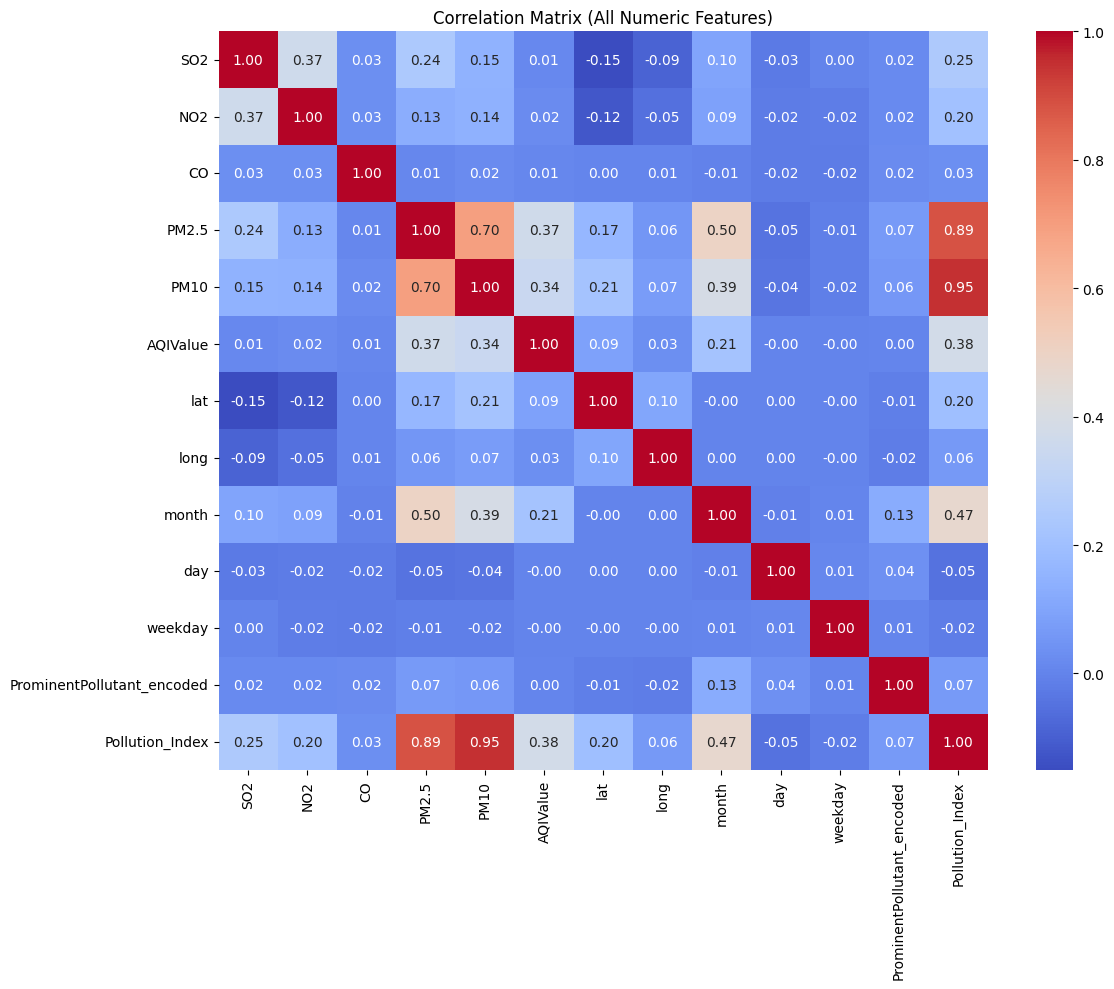

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix (All Numeric Features)")
plt.tight_layout()
plt.show()

### 4.2 Feature Correlation with AQI

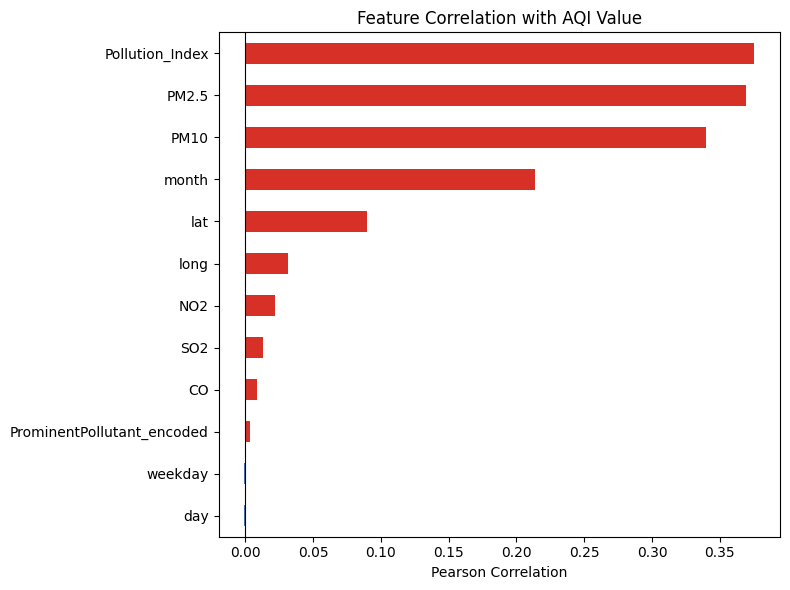

In [ ]:
corr_aqi = df.corr(numeric_only=True)["AQIValue"].drop("AQIValue").sort_values()

plt.figure(figsize=(8, 6))
colors = ["#d73027" if v > 0 else "#4575b4" for v in corr_aqi]
corr_aqi.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with AQI Value")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

### 4.3 AQI Distribution

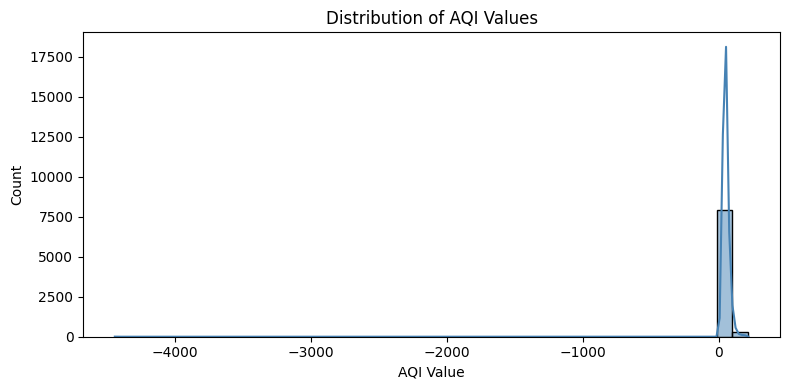

count    8228.000000
mean       51.785773
std        54.904745
min     -4444.000000
25%        37.000000
50%        51.785773
75%        62.000000
max       217.000000
Name: AQIValue, dtype: float64


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["AQIValue"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of AQI Values")
plt.xlabel("AQI Value")
plt.tight_layout()
plt.show()

print(df["AQIValue"].describe())

## 5. Target Variable Creation

> ⚠️ **Important:** The target variable `Pollution_Zone` is created from the **raw (unscaled) AQI values** using meaningful breakpoints. Scaling happens *after* this step to avoid ambiguous bins on a 0–1 range.

AQI range after clipping: -0.5 – 99.5

Bin thresholds — Low < 41.0 | Medium: 41.0–55.0 | High > 55.0

Class distribution:
Pollution_Zone
Low       2760
Medium    2741
High      2727
Name: count, dtype: int64


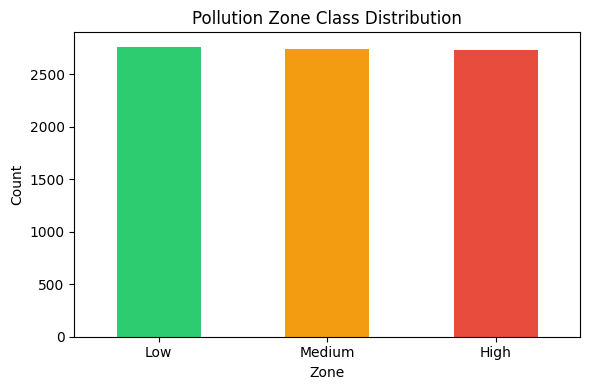

In [ ]:
# Outlier clipping before binning (IQR method on raw AQI)
for col in ["PM2.5", "PM10", "NO2", "AQIValue"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("AQI range after clipping:", df["AQIValue"].min(), "–", df["AQIValue"].max())

# Create Pollution Zone using AQI percentiles for robust binning
low_cut  = df["AQIValue"].quantile(0.33)
high_cut = df["AQIValue"].quantile(0.66)

print(f"\nBin thresholds — Low < {low_cut:.1f} | Medium: {low_cut:.1f}–{high_cut:.1f} | High > {high_cut:.1f}")

df["Pollution_Zone"] = pd.cut(
    df["AQIValue"],
    bins=[df["AQIValue"].min() - 1, low_cut, high_cut, df["AQIValue"].max()],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print("\nClass distribution:")
print(df["Pollution_Zone"].value_counts())

# Plot class balance
plt.figure(figsize=(6, 4))
df["Pollution_Zone"].value_counts().plot(kind="bar", color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Pollution Zone Class Distribution")
plt.xlabel("Zone")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Feature Selection, Scaling & Train-Test Split

### 6.1 Drop Low-Impact & Redundant Features

In [ ]:
# Drop: encoded pollutant (low AQI correlation), raw text column, CO and SO2 (low variance/correlation)
cols_to_drop = ["ProminentPollutant_encoded", "ProminentPollutant", "CO", "SO2", "Date"]
df = df.drop(cols_to_drop, axis=1, errors="ignore")

print("Remaining columns:", list(df.columns))

Remaining columns: ['District 2', 'NO2', 'PM2.5', 'PM10', 'AQIValue', 'lat', 'long', 'month', 'day', 'weekday', 'Pollution_Index', 'Pollution_Zone']


### 6.2 Define Features & Target

In [ ]:
  features = ["PM2.5", "PM10", "NO2", "Pollution_Index", "lat", "long", "month"]

  # Keep only features that exist in df
  features = [f for f in features if f in df.columns]
  print("Selected features:", features)

  # Drop rows with any NaN in features or target
  df_clean = df.dropna(subset=features + ["Pollution_Zone"]).copy()
  print(f"\nRows before cleaning: {len(df)} | After cleaning: {len(df_clean)}")

  X = df_clean[features]
  y = df_clean["Pollution_Zone"]

Selected features: ['PM2.5', 'PM10', 'NO2', 'Pollution_Index', 'lat', 'long', 'month']

Rows before cleaning: 8228 | After cleaning: 8228


### 6.3 Train-Test Split (before scaling to prevent data leakage)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print("\nClass balance in train:")
print(y_train.value_counts())

Training samples: 6582 | Test samples: 1646

Class balance in train:
Pollution_Zone
Low       2208
Medium    2193
High      2181
Name: count, dtype: int64


### 6.4 Feature Scaling (fit on train, transform both)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit ONLY on training data — transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features)

print("Scaling complete. Feature ranges (train):")
print(X_train_scaled.describe().loc[["min", "max"]])

Scaling complete. Feature ranges (train):
     PM2.5  PM10  NO2  Pollution_Index  lat  long  month
min    0.0   0.0  0.0              0.0  0.0   0.0    0.0
max    1.0   1.0  1.0              1.0  1.0   1.0    1.0


## 7. Baseline Model Training & Evaluation

Four baseline classifiers are trained and compared:
- **Logistic Regression** — linear boundary, interpretable
- **Decision Tree** — rule-based, prone to overfitting
- **Random Forest** — ensemble of trees, robust
- **K-Nearest Neighbors (KNN)** — distance-based, sensitive to scale

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5)
}

results      = {}
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Cross-validation (5-fold) on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1_weighted")

    results[name] = {
        "Accuracy":      accuracy_score(y_test, y_pred),
        "Precision":     precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall":        recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score":      f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "CV F1 (mean)": cv_scores.mean(),
        "CV F1 (std)":  cv_scores.std()
    }

    trained_models[name] = (model, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"  CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  Logistic Regression
              precision    recall  f1-score   support

        High       0.98      0.90      0.94       546
         Low       0.95      0.96      0.95       552
      Medium       0.87      0.93      0.90       548

    accuracy                           0.93      1646
   macro avg       0.93      0.93      0.93      1646
weighted avg       0.93      0.93      0.93      1646

  CV F1: 0.9223 ± 0.0078

  Decision Tree
              precision    recall  f1-score   support

        High       1.00      0.99      1.00       546
         Low       0.99      1.00      0.99       552
      Medium       0.99      0.99      0.99       548

    accuracy                           0.99      1646
   macro avg       0.99      0.99      0.99      1646
weighted avg       0.99      0.99      0.99      1646

  CV F1: 0.9927 ± 0.0026

  Random Forest
              precision    recall  f1-score   support

        High       1.00      0.99      0.99       546
         Low       0.9

## 8. Model Comparison

### 8.1 Performance Summary Table

In [ ]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("F1 Score", ascending=False)

print("Model Performance Summary (sorted by F1 Score):")
display(results_df.style.highlight_max(axis=0, color="#c8f7c5").highlight_min(axis=0, color="#f7c5c5"))

Model Performance Summary (sorted by F1 Score):


,Accuracy,Precision,Recall,F1 Score,CV F1 (mean),CV F1 (std)
Decision Tree,0.992700,0.992700,0.992700,0.992700,0.992700,0.002600
Random Forest,0.992100,0.992100,0.992100,0.992100,0.995000,0.003000
Logistic Regression,0.928900,0.931900,0.928900,0.929400,0.922300,0.007800
KNN,0.914300,0.915100,0.914300,0.914600,0.914600,0.005300


### 8.2 Bar Chart Comparison

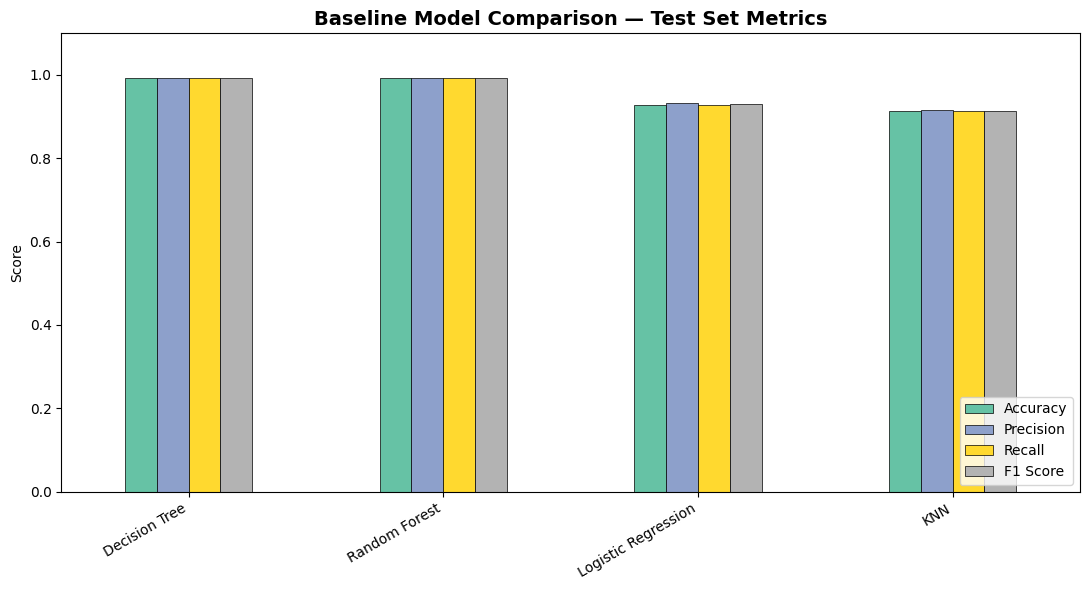

In [ ]:
plot_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results_df[plot_cols].plot(
    kind="bar", figsize=(11, 6),
    colormap="Set2", edgecolor="black", linewidth=0.5
)
plt.title("Baseline Model Comparison — Test Set Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.3 Cross-Validation F1 Comparison

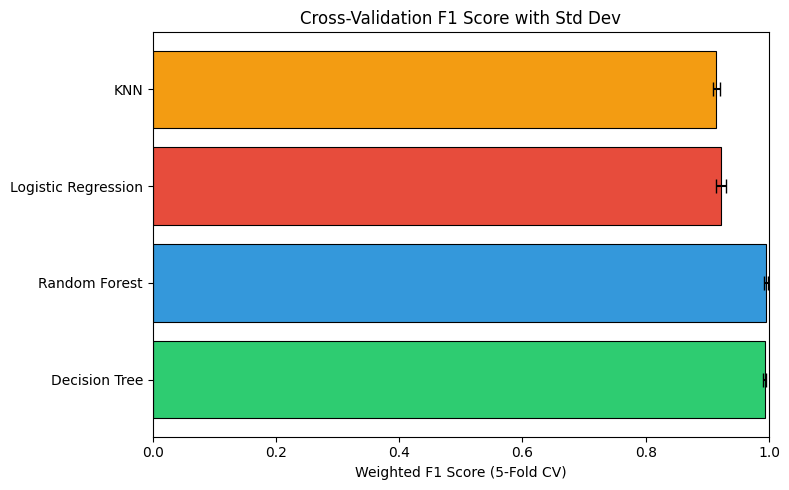

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

model_names = list(results_df.index)
cv_means    = results_df["CV F1 (mean)"].values
cv_stds     = results_df["CV F1 (std)"].values

colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]

ax.barh(model_names, cv_means, xerr=cv_stds,
        color=colors[:len(model_names)], edgecolor="black",
        capsize=5, linewidth=0.8)
ax.set_xlabel("Weighted F1 Score (5-Fold CV)")
ax.set_title("Cross-Validation F1 Score with Std Dev")
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()

### 8.4 Confusion Matrices for All Models

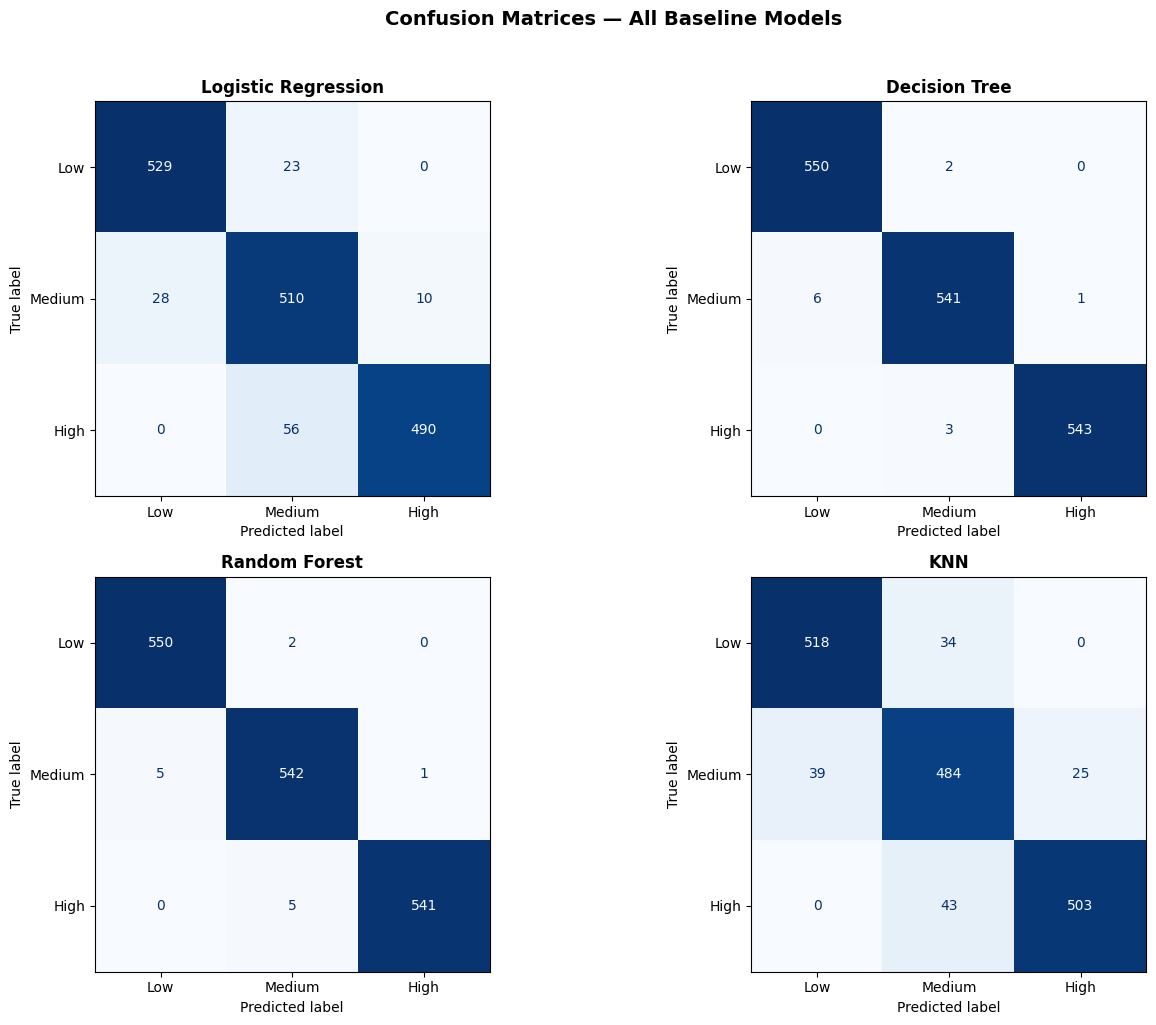

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

class_labels = ["Low", "Medium", "High"]

for i, (name, (model, y_pred)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{name}", fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices — All Baseline Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8.5 Best Model Summary

Identify the best performing model based on F1 Score.

In [ ]:
best_model_name = results_df["F1 Score"].idxmax()
best_model = trained_models[best_model_name][0]
best_score      = results_df.loc[best_model_name, "F1 Score"]

print(f" Best Model: {best_model_name}")
print(f"   Weighted F1 Score: {best_score:.4f}")
print()
print("Full metrics:")
print(results_df.loc[best_model_name])

 Best Model: Decision Tree
   Weighted F1 Score: 0.9927

Full metrics:
Accuracy        0.9927
Precision       0.9927
Recall          0.9927
F1 Score        0.9927
CV F1 (mean)    0.9927
CV F1 (std)     0.0026
Name: Decision Tree, dtype: float64


## 9. Green Infrastructure Recommendation System

Based on predicted `Pollution_Zone` and geographic location (latitude + longitude), each area is assigned a targeted green solution:

| Zone   | Location Context    | Recommendation                     |
|--------|---------------------|------------------------------------|
| High   | Dense/urban (high lat+long score) | Green Walls + Vertical Gardens |
| High   | Peripheral          | Urban Forest + Dense Plantation    |
| Medium | Any                 | Roadside Trees + Green Roofs       |
| Low    | Any                 | Maintain Existing Greenery         |

In [ ]:
# Compute Location Score on the full clean dataset (raw lat/long, not scaled)
df_clean = df_clean.copy()
df_clean["Location_Score"] = df_clean["lat"] + df_clean["long"]
location_median = df_clean["Location_Score"].median()

def recommend_green_solution(row):
    zone = row["Pollution_Zone"]
    loc  = row["Location_Score"]

    if zone == "High":
        if loc > location_median:
            return "Green Walls + Vertical Gardens"
        else:
            return "Urban Forest + Dense Plantation"
    elif zone == "Medium":
        return "Roadside Trees + Green Roofs"
    else:  # Low
        return "Maintain Existing Greenery"

df_clean["Recommendation"] = df_clean.apply(recommend_green_solution, axis=1)

print("Recommendation Distribution:")
print(df_clean["Recommendation"].value_counts())

Recommendation Distribution:
Recommendation
Maintain Existing Greenery         2760
Roadside Trees + Green Roofs       2741
Green Walls + Vertical Gardens     1542
Urban Forest + Dense Plantation    1185
Name: count, dtype: int64


### 9.1 Recommendation Distribution Plot

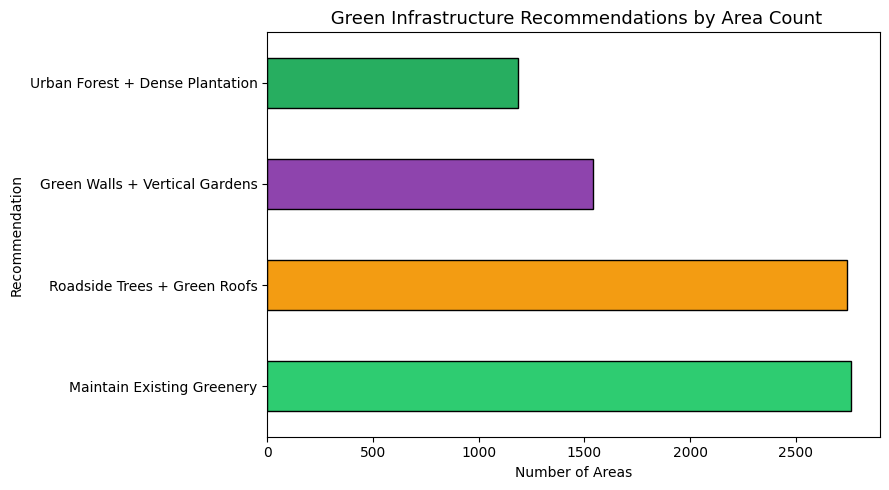

In [ ]:
palette = {
    "Green Walls + Vertical Gardens":   "#8e44ad",
    "Urban Forest + Dense Plantation":  "#27ae60",
    "Roadside Trees + Green Roofs":     "#f39c12",
    "Maintain Existing Greenery":       "#2ecc71"
}

rec_counts = df_clean["Recommendation"].value_counts()
colors = [palette.get(r, "#95a5a6") for r in rec_counts.index]

plt.figure(figsize=(9, 5))
rec_counts.plot(kind="barh", color=colors, edgecolor="black")
plt.title(" Green Infrastructure Recommendations by Area Count", fontsize=13)
plt.xlabel("Number of Areas")
plt.tight_layout()
plt.show()

### 9.2 Sample Output — Pollution Zones & Recommendations

In [ ]:
output_cols = ["AQIValue", "PM2.5", "PM10", "NO2", "Pollution_Zone", "Recommendation"]
available   = [c for c in output_cols if c in df_clean.columns]

display(df_clean[available].head(15))

,AQIValue,PM2.5,PM10,NO2,Pollution_Zone,Recommendation
0,32.000000,15.000000,32.00000,11.000000,Low,Maintain Existing Greenery
1,41.000000,25.000000,38.00000,15.000000,Low,Maintain Existing Greenery
2,50.000000,12.000000,50.00000,23.500000,Medium,Roadside Trees + Green Roofs
3,53.000000,14.000000,-1.50000,9.000000,Medium,Roadside Trees + Green Roofs
4,99.000000,18.000000,98.50000,15.000000,High,Green Walls + Vertical Gardens
5,52.000000,13.000000,52.00000,23.500000,Medium,Roadside Trees + Green Roofs
6,68.000000,35.000000,68.00000,19.000000,High,Urban Forest + Dense Plantation
7,31.000000,14.000000,31.00000,12.000000,Low,Maintain Existing Greenery
8,20.000000,12.000000,15.00000,14.000000,Low,Maintain Existing Greenery
9,23.000000,11.000000,23.00000,12.000000,Low,Maintain Existing Greenery


### 9.3 Save Final Results to Excel

In [ ]:
df_clean[available].to_excel("pollution_hotspots_recommendations.xlsx", index=False)
print("✅ Results saved to 'pollution_hotspots_recommendations.xlsx'")

✅ Results saved to 'pollution_hotspots_recommendations.xlsx'


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc  = le_target.transform(y_test)

print(le_target.classes_)  # ['High', 'Low', 'Medium'] (order may vary)

['High' 'Low' 'Medium']


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Input layer
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer (3 classes)
model.add(Dense(3, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,283 (67.51 KB)

 Trainable params: 17,283 (67.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_scaled, y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7062 - loss: 0.6857 - val_accuracy: 0.8853 - val_loss: 0.3434
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8883 - loss: 0.3031 - val_accuracy: 0.9294 - val_loss: 0.1952
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9094 - loss: 0.2411 - val_accuracy: 0.9301 - val_loss: 0.1780
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9235 - loss: 0.2083 - val_accuracy: 0.9560 - val_loss: 0.1439
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9362 - loss: 0.1864 - val_accuracy: 0.9537 - val_loss: 0.1337
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9347 - loss: 0.1858 - val_accuracy: 0.9415 - val_loss: 0.1528
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9425 - loss: 0.1695 - val_accuracy: 0.9423 - val_loss: 0.1405
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9426 - loss: 0.1659 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import classification_report

# Predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1)

# Convert back to labels
y_pred_labels = le_target.inverse_transform(y_pred)

print(classification_report(y_test, y_pred_labels))

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

        High       0.95      0.99      0.97       546
         Low       0.98      0.96      0.97       552
      Medium       0.96      0.92      0.94       548

    accuracy                           0.96      1646
   macro avg       0.96      0.96      0.96      1646
weighted avg       0.96      0.96      0.96      1646



In [ ]:
from sklearn.metrics import accuracy_score, f1_score

dl_accuracy = accuracy_score(y_test, y_pred_labels)
dl_f1 = f1_score(y_test, y_pred_labels, average='weighted')

print("Deep Learning Model:")
print("Accuracy:", dl_accuracy)
print("F1 Score:", dl_f1)

Deep Learning Model:
Accuracy: 0.959902794653706
F1 Score: 0.959717392939978


In [ ]:
import os

os.makedirs("data", exist_ok=True)

df_sample = df_clean.sample(50, random_state=42)
df_sample.to_excel("data/sample_data.xlsx", index=False)

In [ ]:
import os
print(os.listdir("data"))

['sample_data.xlsx']


In [ ]:
from google.colab import files
files.download("data/sample_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")

print("✅ Model saved")

✅ Model saved


In [ ]:
import os
print(os.listdir("models"))

['best_model.pkl']


In [ ]:
import joblib

joblib.dump(best_model, "best_model.pkl")

print("✅ Model saved!")

✅ Model saved!


In [ ]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>